**Michigan Electrical Grid Demand Fluctuations: Assessing Data Center Feasibility**
This project analyzes the relationship between Michigan electricity demand and weather patterns to determine whether new data centers might overload the system at peak usage periods. 

**Data:** 
Electrical data was obtained via API from EIA: US Energy Information Administration https://www.eia.gov/opendata/index.php, first downloaded on Nov. 26, 2025.
Climate data was obtained via download from NOAA climate data: https://www.ncei.noaa.gov/cdo-web/ on Nov. 26, 2025
The key for this data is here: https://www1.ncdc.noaa.gov/pub/data/ghcn/daily/readme.txt 
The models are trained on data from 2022-2023 and tested on data from 2024.
The airport weather station in Lansing, MI, is used as a representative climate point for the state of Michigan. 

**Methods and Python Libraries:**
This project analyzes the data using a multiple linear regression model using the Python library statsmodels: https://www.statsmodels.org/stable/index.html 
For data manipulation, I will use Pandas https://pandas.pydata.org/docs/user_guide/index.html
For number crunching and stats tests, I will use NumPy https://numpy.org/ and SciPy https://scipy.org/
For plotting, I will choose from Matplotlib https://matplotlib.org/ and seaborn https://seaborn.pydata.org/

In [1]:
# Import Python Libraries

# Data Manipulation and Stats
import pandas as pd 
import numpy as np 
from scipy import stats 

# Plotting
import matplotlib.pyplot as plt 
import seaborn as sns 

# Modeling
from statsmodels.api import OLS, add_constant # linear regression
# from statsmodels.tsa.statespace.sarimax import SARIMAX # for future analysis
# import statsmodels.graphics.tsaplots as tsaplots # option for plotting auto-correlation functions for SARIMA  


In [2]:
# Explore EIA data

elec_demand_raw = pd.read_csv('elec_demand_raw.csv')

elec_demand_raw.info()  # Column names, data types, non-null counts
elec_demand_raw.shape  # (rows, columns)

elec_demand_raw.describe()  # Mean, std, min, max, quartiles for numeric columns

elec_demand_raw.isnull().sum()  # Count of nulls in each column

elec_demand_raw.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26230 entries, 0 to 26229
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   period       26230 non-null  object
 1   subba        26230 non-null  int64 
 2   subba-name   26230 non-null  object
 3   parent       26230 non-null  object
 4   parent-name  26230 non-null  object
 5   value        26230 non-null  int64 
 6   value-units  26230 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.4+ MB


,period,subba,subba-name,parent,parent-name,value,value-units
0,2024-12-31T00,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",17928,megawatthours
1,2024-12-30T23,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",17504,megawatthours
2,2024-12-30T22,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",16786,megawatthours
3,2024-12-30T21,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",16634,megawatthours
4,2024-12-30T20,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",16730,megawatthours
5,2024-12-30T19,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",16911,megawatthours
6,2024-12-30T18,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",17047,megawatthours
7,2024-12-30T17,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",17189,megawatthours
8,2024-12-30T16,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",17280,megawatthours
9,2024-12-30T15,27,Zones 2 and 7,MISO,"Midcontinent Independent System Operator, Inc.",17185,megawatthours


In [3]:
# Load NOAA and explore climate data

weather_raw = pd.read_csv("Lansing_Airport_2022_2024.csv")

weather_raw.info()  # Column names, data types, non-null counts - I don't think it did this one
weather_raw.shape  # (rows, columns)

weather_raw.describe()  # Mean, std, min, max, quartiles for numeric columns - I don't think it did this one either

weather_raw.isnull().sum()  # Count of nulls in each column

weather_raw.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Columns: 120 entries, STATION to WV03_ATTRIBUTES
dtypes: float64(86), int64(6), object(28)
memory usage: 1.0+ MB


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,ACMH,ACMH_ATTRIBUTES,ACSH,ACSH_ATTRIBUTES,...,WT18,WT18_ATTRIBUTES,WT19,WT19_ATTRIBUTES,WT21,WT21_ATTRIBUTES,WT22,WT22_ATTRIBUTES,WV03,WV03_ATTRIBUTES
0,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/1/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/2/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/3/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/4/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/5/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/6/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/7/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/8/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/9/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,USW00014836,"LANSING CAPITAL CITY AIRPORT, MI US",42.77609,-84.59972,261.2,1/10/2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Remove empty or unnecessary columns from NOAA data

# Remove empty columns (dropped from 120 to 56 columns)
weather_col_removed = weather_raw.dropna(axis=1, how='all')
weather_col_removed.head(10)

# Check for columns with lots of NaN
nan_percent = weather_col_removed.isnull().sum() / len(weather_col_removed) * 100
print(nan_percent)

# Delete 14 columns without pertinence to this project (gust times, directions, fastest gust, thunder, smoke)
columns_to_drop = ['PGTM', # peak gust time
    'PGTM_ATTRIBUTES', 
    'WDF2', # direction of fastest 2 min wind
    'WDF2_ATTRIBUTES',
    'WDF5', # direction of fastest 5 second wind
    'WDF5_ATTRIBUTES',
    'WSF2', # fastest 2 min wind speed
    'WSF2_ATTRIBUTES',
    'WSF5', # fastest 5 sec wind speed
    'WSF5_ATTRIBUTES',
    'WT03', # thunder
    'WT03_ATTRIBUTES',
    'WT08', # smoke or haze
    'WT08_ATTRIBUTES']

weather_col_removed = weather_col_removed.drop(columns=columns_to_drop, errors='ignore')

STATION             0.000000
NAME                0.000000
LATITUDE            0.000000
LONGITUDE           0.000000
ELEVATION           0.000000
DATE                0.000000
ADPT                0.091241
ADPT_ATTRIBUTES     0.091241
ASLP                0.182482
ASLP_ATTRIBUTES     0.182482
ASTP                0.182482
ASTP_ATTRIBUTES     0.182482
AWBT                0.091241
AWBT_ATTRIBUTES     0.091241
AWND                2.919708
AWND_ATTRIBUTES     2.919708
PGTM               96.715328
PGTM_ATTRIBUTES    96.715328
PRCP                0.000000
PRCP_ATTRIBUTES     0.000000
RHAV                0.000000
RHAV_ATTRIBUTES     0.000000
RHMN                0.000000
RHMN_ATTRIBUTES     0.000000
RHMX                0.000000
RHMX_ATTRIBUTES     0.000000
SNOW                0.000000
SNOW_ATTRIBUTES     0.000000
SNWD                0.000000
SNWD_ATTRIBUTES     0.000000
TAVG                0.000000
TAVG_ATTRIBUTES     0.000000
TMAX                0.000000
TMAX_ATTRIBUTES     0.000000
TMIN          

In [5]:
# NOAA Weather replace NaNs with interpolations or 0 as appropriate

weather_cleaned = weather_col_removed

# check for long clumps of NaNs in dew point temp, sea level pressure, station level pressure, wet bulb temp, avg wind speed
#for col in ['ADPT', 'ASLP', 'ASTP', 'AWBT', 'AWND']:
#    print(f"\n{col}:")
#    print(weather_cleaned[col].isna().value_counts())
    
#    # Find consecutive NaN chunks
#    nan_groups = weather_cleaned[col].isna().astype(int).groupby(weather_cleaned[col].notna().astype(int).cumsum()).sum()
#    print(f"Longest consecutive NaN streak: {nan_groups.max()}")

# Results show there are only singleton NaNs for 'ADPT', 'ASLP', 'ASTP', 'AWBT', not clumps = use linear interpolation to fill values
#sort values to make sure data is sorted by date, which is in a date format
weather_cleaned['DATE'] = pd.to_datetime(weather_cleaned['DATE'])
print(weather_cleaned['DATE'].dtype)
print(weather_cleaned['DATE'].head(10))

weather_cleaned = weather_cleaned.sort_values('DATE')
weather_cleaned = weather_cleaned.reset_index(drop=True)

# use linear interpolation to fill NaNs
weather_cleaned[['ADPT', 'ASLP', 'ASTP', 'AWBT']] = \
    weather_cleaned[['ADPT', 'ASLP', 'ASTP', 'AWBT']].interpolate(method='linear')

# Find dates of 9 day streak in wind speed (AWND)
#is_nan = weather_cleaned['AWND'].isna() # mask where NaNs are
#nan_groups = is_nan.ne(is_nan.shift()).cumsum() # find groups
#nan_streak_lengths = weather_cleaned[is_nan].groupby(nan_groups[is_nan]).size() 
#longest_streak_group = nan_streak_lengths.idxmax() 
#longest_streak_dates = weather_cleaned[is_nan & (nan_groups == longest_streak_group)][['DATE', 'AWND']]
#print(longest_streak_dates)

# Since longest streak is in the training set (2022-23), use forward fill to replace NaNs
weather_cleaned['AWND'] = weather_cleaned['AWND'].ffill()

# Replace the NaNs in the binary categories 'WT01' (Fog, ice fog, or freezing fog), 'WT02' (heavy fog), 'WT06' (glaze or rime), 'WT09' (blowing snow)
weather_cleaned[['WT01', 'WT02', 'WT06', 'WT09']] = weather_cleaned[['WT01', 'WT02', 'WT06', 'WT09']].fillna(0) 


datetime64[ns]
0   2022-01-01
1   2022-01-02
2   2022-01-03
3   2022-01-04
4   2022-01-05
5   2022-01-06
6   2022-01-07
7   2022-01-08
8   2022-01-09
9   2022-01-10
Name: DATE, dtype: datetime64[ns]


In [6]:
# Verification checks on NOAA weather data

# NOAA data uses 9999 for missing values - none found
#print((weather_cleaned == 9999).sum())

# Check for extra NaNs - only in the attribute metadata columns, so they are fine.
#print(weather_cleaned.isna().sum())

# Check data types 
# print(weather_cleaned.dtypes)

# Check values one more time
#print(weather_cleaned.describe())

# Check the date order
#print(weather_cleaned['DATE'].head())


In [7]:
# Clean and aggregate electric demand data
elec_demand_clean = pd.read_csv('elec_demand_raw.csv')

# Peek at the data
#print(elec_demand_clean.head())
#print(elec_demand_clean.dtypes)
#print(elec_demand_clean.shape)

# Convert period to a date
elec_demand_clean['period'] = pd.to_datetime(elec_demand_clean['period'])
elec_demand_clean['DATE'] = elec_demand_clean['period'].dt.date

# Check if all days have 24 hours in them
hours_per_day = elec_demand_clean.groupby('DATE').size()
print("Days with != 24 hours:")
print(hours_per_day[hours_per_day != 24])

# Summary counts show
# print(f"\nTotal unique dates: {len(hours_per_day)}")
# print(f"Days with exactly 24 hours: {(hours_per_day == 24).sum()}")
# print(f"Days with < 24 hours: {(hours_per_day < 24).sum()}")
# print(f"Days with > 24 hours: {(hours_per_day > 24).sum()}")

# 7 days aren't complete: 2022-06-06 (23h); 2022-06-09 (22h); 2024-07-01 (6h);
# 2024-07-02 (18h); 2024-08-26 (6); 2024-08-27 (18); 2024-12-31 (1).

# Check whether there is evidence of an outage on the incomplete days
#incomplete_dates = hours_per_day[hours_per_day != 24].index

#for date in incomplete_dates:
#    print(f"\n{date}:")
#    day_data = elec_demand_clean[elec_demand_clean['DATE'] == date][['period', 'value']].sort_values('period')
#    print(day_data)

# There isn't evidence of an outage. Since the missing hours are mostly in the test data,
# I'll drop the incomplete days before merging with the weather data.
complete_dates = hours_per_day[hours_per_day == 24].index
elec_demand_clean = elec_demand_clean[elec_demand_clean['DATE'].isin(complete_dates)]

# check how many days kept
#print(f"Kept {len(complete_dates)} complete days out of {len(hours_per_day)} total")

# Check for weird values
#print(elec_demand_clean['value'].describe())
#print(f"\nMin demand: {elec_demand_clean['value'].min()}")
#print(f"Max demand: {elec_demand_clean['value'].max()}")

# Check for any zeros or suspiciously low values
#print(f"\nValues below 10,000 MWh:")
#print(elec_demand_clean[elec_demand_clean['value'] < 10000][['period', 'value']])

# Check for any extreme highs
#print(f"\nValues above 30,000 MWh:")
#print(elec_demand_clean[elec_demand_clean['value'] > 30000][['period', 'value']])

# All values seem good. Aggregate by day.
elec_demand_daily = elec_demand_clean.groupby('DATE').agg({
    'value': 'sum'
}).reset_index()

# rename column for clarity
elec_demand_daily.rename(columns={'value': 'daily_demand_MWh'}, inplace=True)

# convert date to datetime and sort
elec_demand_daily['DATE'] = pd.to_datetime(elec_demand_daily['DATE'])
elec_demand_daily = elec_demand_daily.sort_values('DATE').reset_index(drop=True)

print(elec_demand_daily.head())
print(elec_demand_daily.shape)
print(elec_demand_daily['daily_demand_MWh'].describe())

Days with != 24 hours:
DATE
2022-06-06    23
2022-06-09    22
2024-07-01     6
2024-07-02    18
2024-08-26     6
2024-08-27    18
2024-12-31     1
dtype: int64
        DATE  daily_demand_MWh
0 2022-01-01            380602
1 2022-01-02            394323
2 2022-01-03            441413
3 2022-01-04            458051
4 2022-01-05            461692
(1089, 2)
count      1089.000000
mean     430930.158861
std       51370.896527
min      332691.000000
25%      397557.000000
50%      421841.000000
75%      455354.000000
max      619072.000000
Name: daily_demand_MWh, dtype: float64


In [8]:
# Merge NOAA and MISO data

electric_cleaned = elec_demand_daily

# use inner join to keep only data that exists in both dataframes 
elec_weather_merged = pd.merge(weather_cleaned, electric_cleaned, on='DATE', how='inner')

print(elec_weather_merged.shape)
print(elec_weather_merged.head())
print(elec_weather_merged['DATE'].min(), 'to', elec_weather_merged['DATE'].max())

(1089, 43)
       STATION                                 NAME  LATITUDE  LONGITUDE  \
0  USW00014836  LANSING CAPITAL CITY AIRPORT, MI US  42.77609  -84.59972   
1  USW00014836  LANSING CAPITAL CITY AIRPORT, MI US  42.77609  -84.59972   
2  USW00014836  LANSING CAPITAL CITY AIRPORT, MI US  42.77609  -84.59972   
3  USW00014836  LANSING CAPITAL CITY AIRPORT, MI US  42.77609  -84.59972   
4  USW00014836  LANSING CAPITAL CITY AIRPORT, MI US  42.77609  -84.59972   

   ELEVATION       DATE  ADPT ADPT_ATTRIBUTES   ASLP ASLP_ATTRIBUTES  ...  \
0      261.2 2022-01-01  27.0             ,,W  29.84             ,,W  ...   
1      261.2 2022-01-02   8.0             ,,W  30.13             ,,W  ...   
2      261.2 2022-01-03   9.0             ,,W  30.32             ,,W  ...   
3      261.2 2022-01-04  18.0             ,,W  30.04             ,,W  ...   
4      261.2 2022-01-05  18.0             ,,W  29.61             ,,W  ...   

   TMIN_ATTRIBUTES WT01  WT01_ATTRIBUTES WT02  WT02_ATTRIBUTES WT06  

In [9]:
# Split training (2022-2023) and test (2024) data apart
train_df = elec_weather_merged[elec_weather_merged['DATE'] < '2024-01-01'].copy()
test_df = elec_weather_merged[elec_weather_merged['DATE'] >= '2024-01-01'].copy()

print(f"Training: {train_df.shape[0]} days (2022-2023)")
print(f"Test: {test_df.shape[0]} days (2024)")

Training: 728 days (2022-2023)
Test: 361 days (2024)


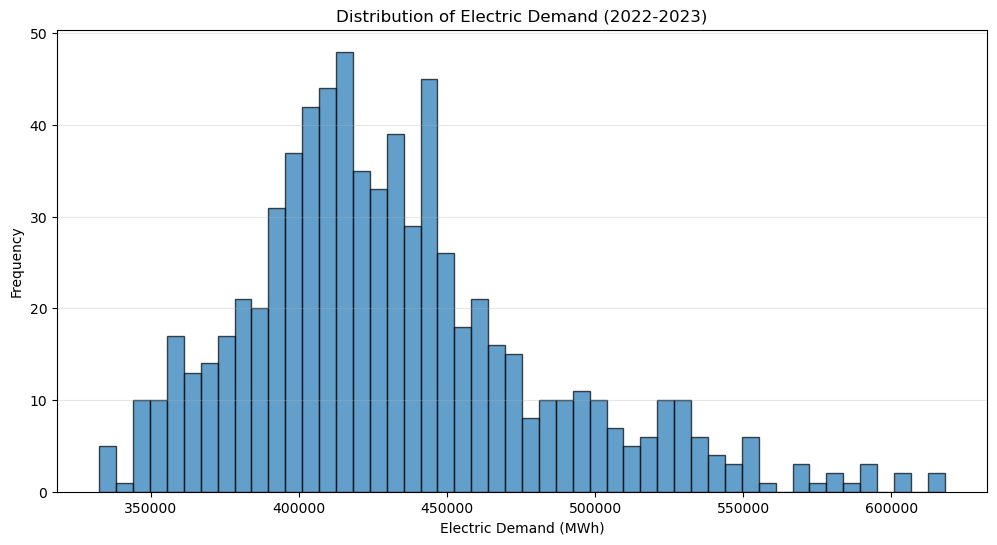

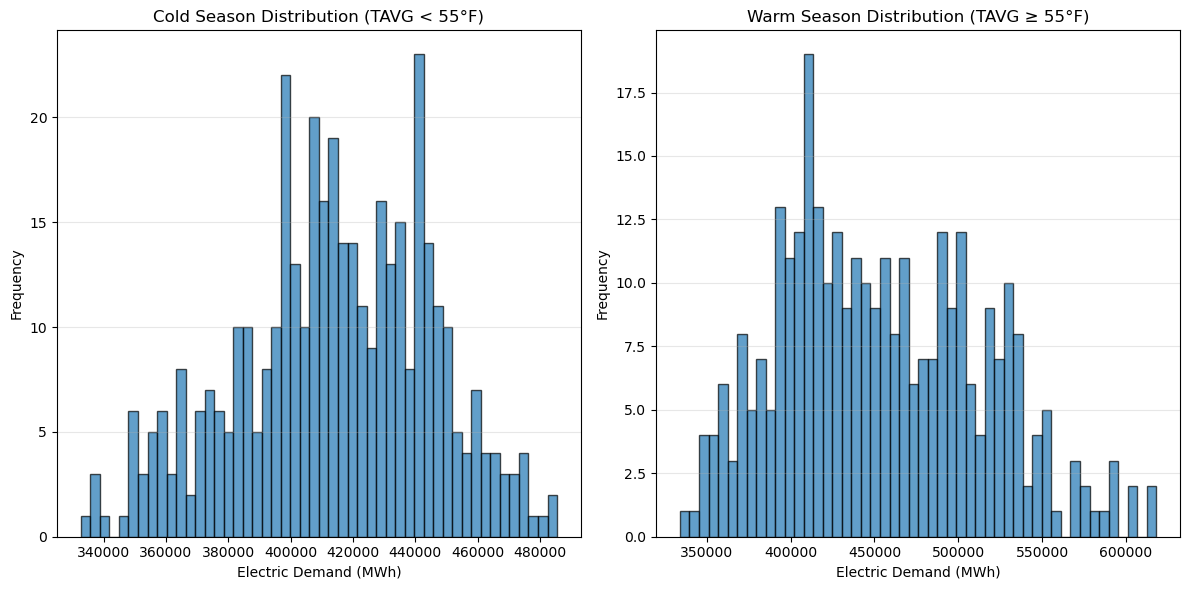

In [10]:
# Histogram of Training Data Electricity Demand

plt.figure(figsize=(12, 6))
plt.hist(train_df.daily_demand_MWh, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Electric Demand (MWh)')
plt.ylabel('Frequency')
plt.title('Distribution of Electric Demand (2022-2023)')
plt.grid(axis='y', alpha=0.3)
plt.savefig('electric_demand_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

cold_season = train_df[train_df['TAVG'] < 55].copy()
warm_season = train_df[train_df['TAVG'] >= 55].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.hist(cold_season.daily_demand_MWh, bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Electric Demand (MWh)')
ax1.set_ylabel('Frequency')
ax1.set_title('Cold Season Distribution (TAVG < 55°F)')
ax1.grid(axis='y', alpha=0.3)

ax2.hist(warm_season.daily_demand_MWh, bins=50, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Electric Demand (MWh)')
ax2.set_ylabel('Frequency')
ax2.set_title('Warm Season Distribution (TAVG ≥ 55°F)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('electric_demand_seasons.png', dpi=300, bbox_inches='tight')
plt.show()

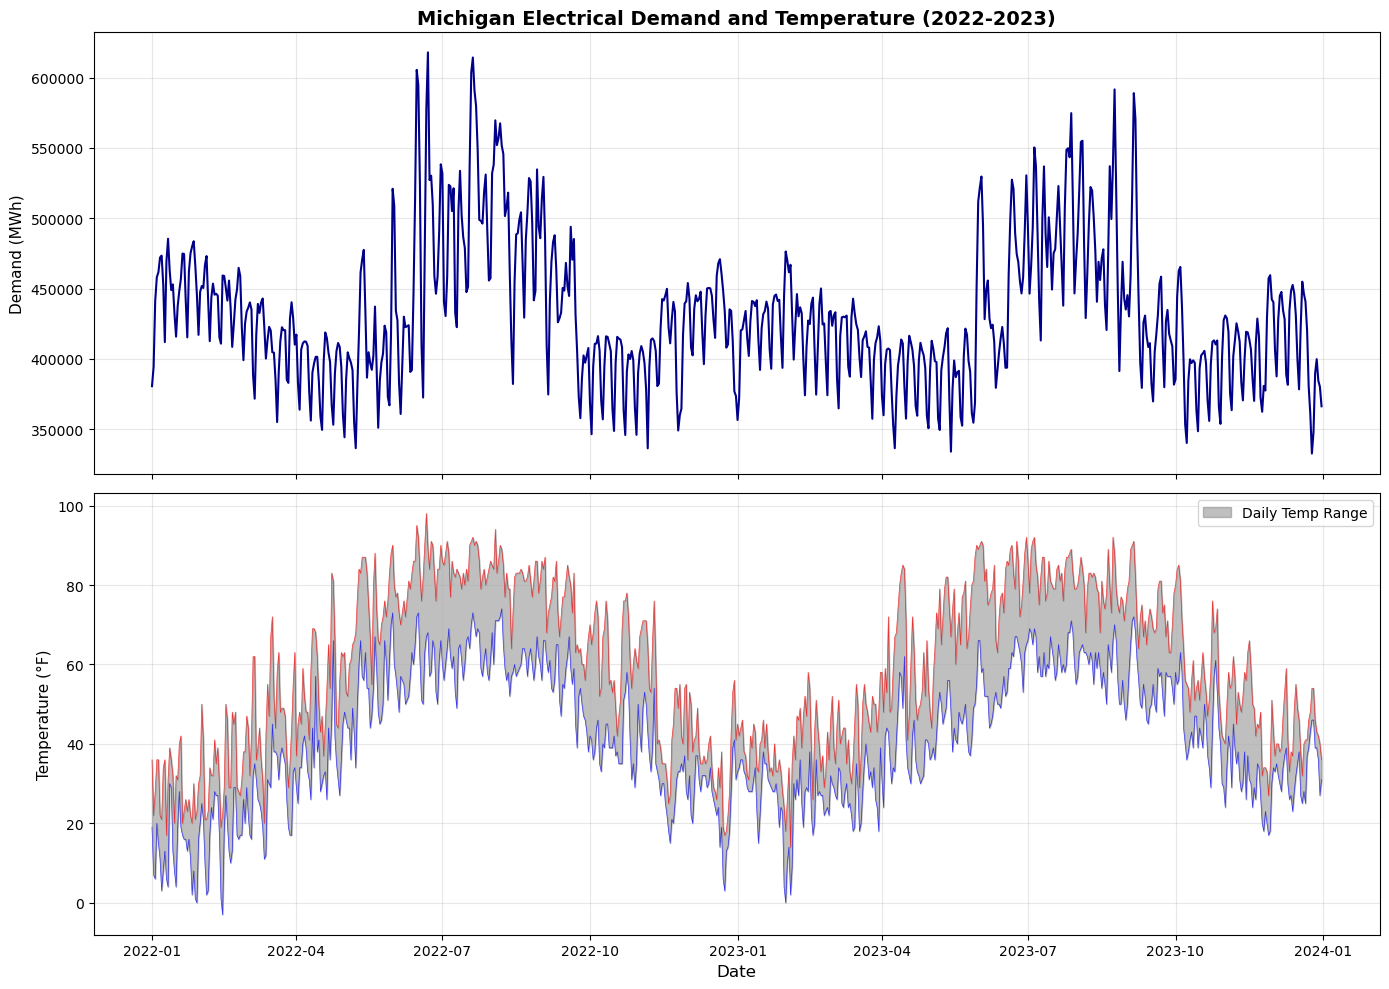

In [11]:
# Training data stats and visualizations

# ----- Time Series plots of daily electrical demand and temperature range -----
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Demand line plot
axes[0].plot(train_df['DATE'], train_df['daily_demand_MWh'], color='darkblue', linewidth=1.5)
axes[0].set_ylabel('Demand (MWh)', fontsize=11)
axes[0].set_title('Michigan Electrical Demand and Temperature (2022-2023)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Temperature range chart
axes[1].fill_between(train_df['DATE'], train_df['TMIN'], train_df['TMAX'], 
                      color='gray', alpha=0.5, label='Daily Temp Range')
axes[1].plot(train_df['DATE'], train_df['TMAX'], color='red', linewidth=0.5, alpha=0.7)
axes[1].plot(train_df['DATE'], train_df['TMIN'], color='blue', linewidth=0.5, alpha=0.7)
axes[1].set_ylabel('Temperature (°F)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('demand_temperature_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()


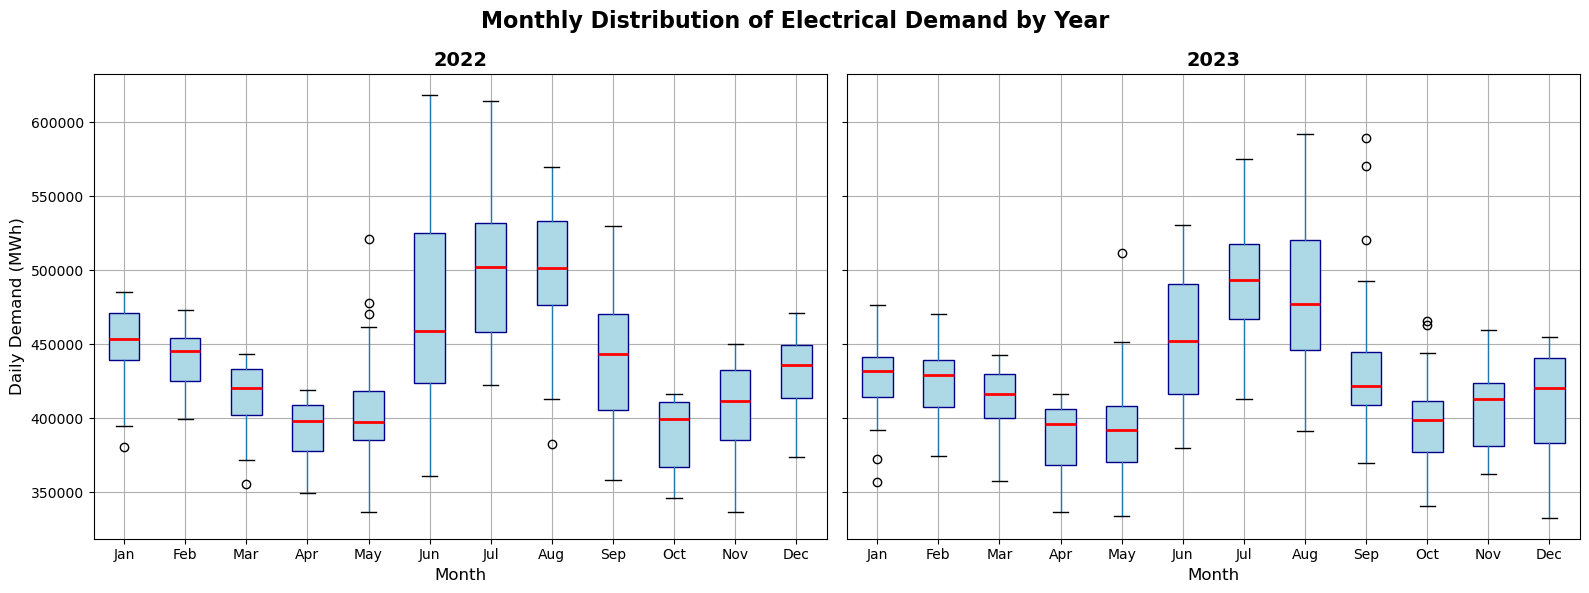

In [12]:
# ----- Box Plot of monthly and annual electrical demand -----
train_df['Month'] = train_df['DATE'].dt.month
train_df['Year'] = train_df['DATE'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

train_2022 = train_df[train_df['Year'] == 2022]
train_2022.boxplot(column='daily_demand_MWh', by='Month', ax=axes[0], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='darkblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[0].set_title('2022', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Daily Demand (MWh)', fontsize=12)
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 2023
train_2023 = train_df[train_df['Year'] == 2023]
train_2023.boxplot(column='daily_demand_MWh', by='Month', ax=axes[1], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='darkblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1].set_title('2023', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.suptitle('Monthly Distribution of Electrical Demand by Year', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_demand_boxplot_by_year.png', dpi=300, bbox_inches='tight')
plt.show()


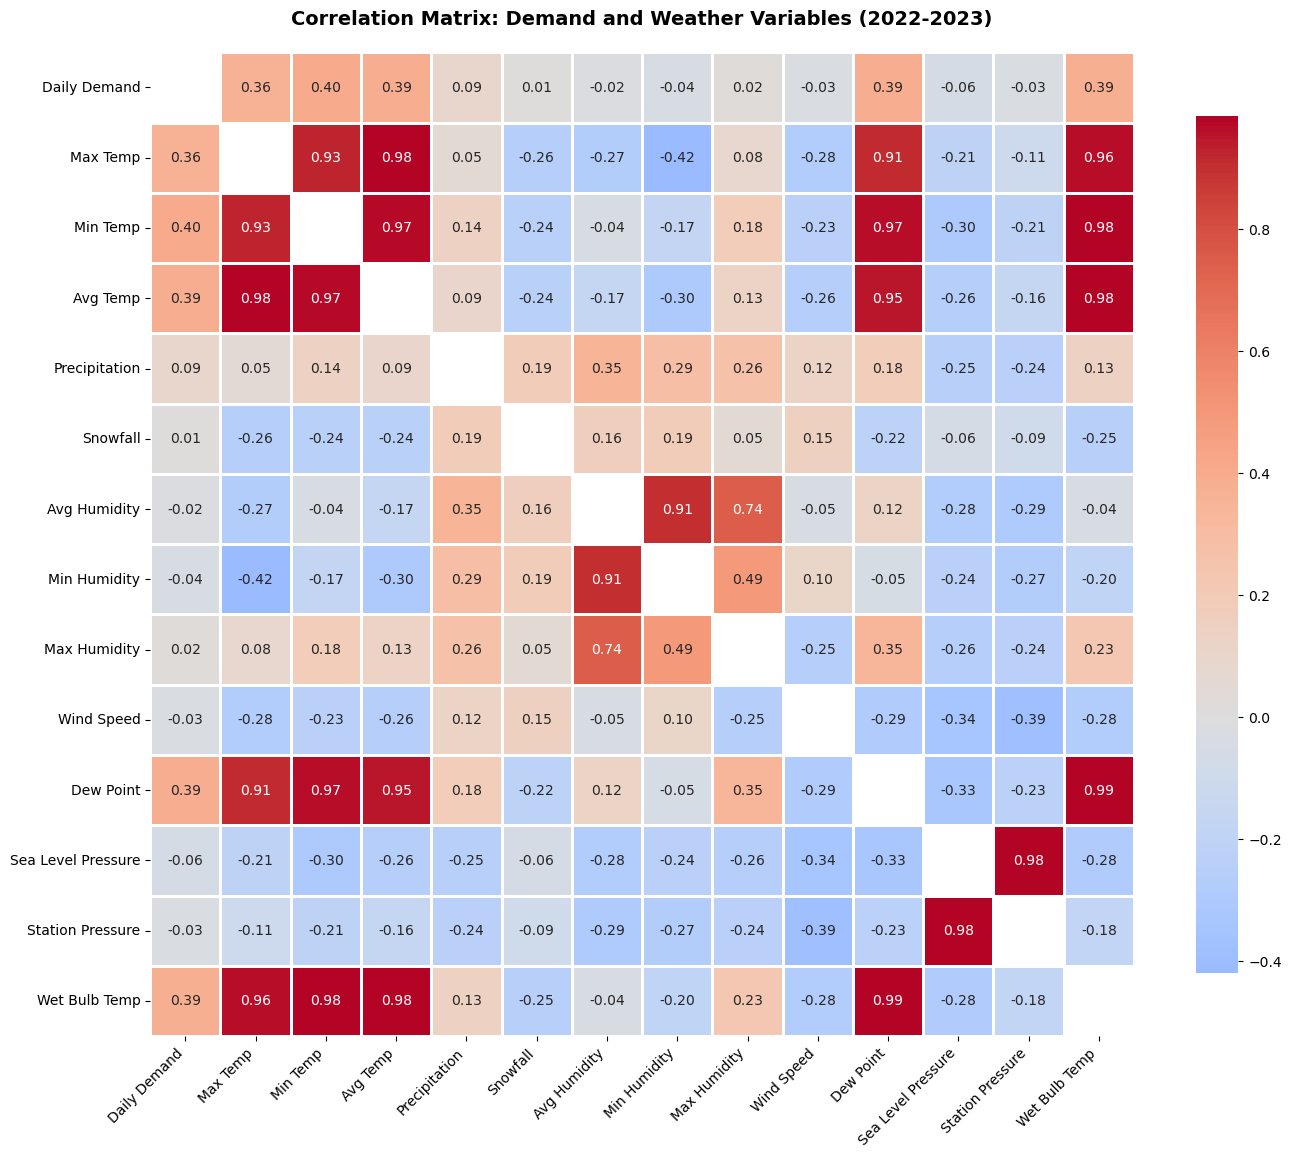

In [13]:
# ----- Correlation heatmap: demand v. weather variables -----

corr_vars = ['daily_demand_MWh', 'TMAX', 'TMIN', 'TAVG', 'PRCP', 'SNOW', 
             'RHAV', 'RHMN', 'RHMX', 'AWND', 'ADPT', 'ASLP', 'ASTP', 'AWBT']

# More descriptive labels
labels = ['Daily Demand', 'Max Temp', 'Min Temp', 'Avg Temp', 'Precipitation', 
          'Snowfall', 'Avg Humidity', 'Min Humidity', 'Max Humidity', 
          'Wind Speed', 'Dew Point', 'Sea Level Pressure', 'Station Pressure', 
          'Wet Bulb Temp']

corr_matrix = train_df[corr_vars].corr()

mask = np.eye(len(corr_matrix), dtype=bool) # Mask the diagonal so it's not red

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            xticklabels=labels, yticklabels=labels, mask=mask)

plt.title('Correlation Matrix: Demand and Weather Variables (2022-2023)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

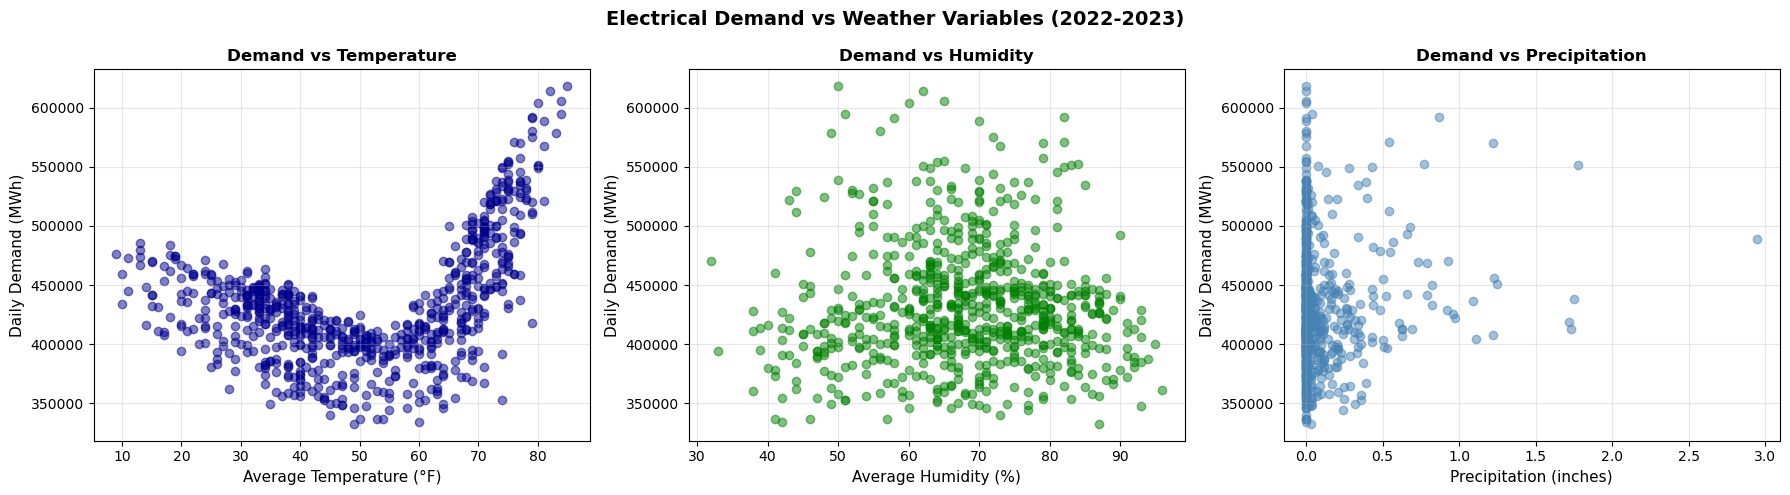

In [14]:
# ----- Scatterplots of demand v. temp, humidity, precipitation -----

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Demand vs Avg Temp
axes[0].scatter(train_df['TAVG'], train_df['daily_demand_MWh'], alpha=0.5, color='darkblue')
axes[0].set_xlabel('Average Temperature (°F)', fontsize=11)
axes[0].set_ylabel('Daily Demand (MWh)', fontsize=11)
axes[0].set_title('Demand vs Temperature', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Demand vs Avg Humidity
axes[1].scatter(train_df['RHAV'], train_df['daily_demand_MWh'], alpha=0.5, color='green')
axes[1].set_xlabel('Average Humidity (%)', fontsize=11)
axes[1].set_ylabel('Daily Demand (MWh)', fontsize=11)
axes[1].set_title('Demand vs Humidity', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Demand vs Precipitation
axes[2].scatter(train_df['PRCP'], train_df['daily_demand_MWh'], alpha=0.5, color='steelblue')
axes[2].set_xlabel('Precipitation (inches)', fontsize=11)
axes[2].set_ylabel('Daily Demand (MWh)', fontsize=11)
axes[2].set_title('Demand vs Precipitation', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle('Electrical Demand vs Weather Variables (2022-2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('demand_weather_scatterplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# AIC and BIC model comparison for linear regression
# This is the second run of this comparison. I removed the first run for time. 
# In this run, I removed fog, rime, and blowing snow predictors because they were not in the predictors for 
# the best model for the cold season, but they were showing up in the warm season model.

from itertools import combinations

# Split train data into two sections, < 55 and >=55, to model seasonal demand
cold_season = train_df[train_df['TAVG'] < 55].copy()
warm_season = train_df[train_df['TAVG'] >= 55].copy()
print(f"Cold season: {len(cold_season)} days")
print(f"Warm season: {len(warm_season)} days")

# removed 'WT01', 'WT02', 'WT06', 'WT09' and added the min/max humidity, pressure, dew point, and wet bulb temp
predictors = ['TAVG', 'TMAX', 'TMIN', 'PRCP', 'SNOW', 'SNWD', 
              'RHAV', 'RHMN', 'RHMX', 'AWND', 'ASTP', 'ASLP', 'ADPT', 'AWBT']

def fit_and_compare(data, predictor_list, season_name):
    results = []

    for r in range(1, len(predictor_list) + 1):
        for pred_combo in combinations(predictor_list, r):

            X = data[list(pred_combo)]
            X = add_constant(X)
            y = data['daily_demand_MWh']

            try:
                model = OLS(y, X)
                fit = model.fit()

                results.append({
                    'predictors': ', '.join(pred_combo),
                    'n_predictors': len(pred_combo),
                    'AIC': fit.aic,
                    'BIC': fit.bic,
                    'R2': fit.rsquared,
                    'Adj_R2': fit.rsquared_adj
                })
            except:
                pass

    results_df = pd.DataFrame(results).sort_values('AIC')
    print(f"\n{season_name} - Top 10 Models by AIC:")
    print(results_df.head(10))

    return results_df

cold_results = fit_and_compare(cold_season, predictors, "Cold Season")

warm_results = fit_and_compare(warm_season, predictors, "Warm Season")

Cold season: 402 days
Warm season: 326 days

Cold Season - Top 10 Models by AIC:
                                    predictors  n_predictors          AIC  \
1945              TAVG, PRCP, RHMN, AWND, ASTP             5  9269.981783   
1946              TAVG, PRCP, RHMN, AWND, ASLP             5  9270.650434   
4495        TAVG, PRCP, RHMX, AWND, ASLP, ADPT             6  9270.795907   
1968              TAVG, PRCP, AWND, ASLP, ADPT             5  9270.842088   
4472        TAVG, PRCP, RHMN, RHMX, AWND, ASTP             6  9270.889234   
3727        TAVG, TMAX, PRCP, RHMN, AWND, ASTP             6  9270.994977   
1966              TAVG, PRCP, AWND, ASTP, ADPT             5  9271.015084   
7977  TAVG, PRCP, RHMX, AWND, ASTP, ADPT, AWBT             7  9271.309423   
3728        TAVG, TMAX, PRCP, RHMN, AWND, ASLP             6  9271.342825   
4493        TAVG, PRCP, RHMX, AWND, ASTP, ADPT             6  9271.371650   

              BIC        R2    Adj_R2  
1945  9293.960496  0.392628  0.

In [16]:
# Testing linear regression models with one temperature variable for the warm season
# The top 4 models from the AIC test for the warm days came back with a tie. The simplest of these
# had Average temperature, minimum temperature, and average dew point, which are all correlated.
# This cell tests which of the temperatures (avg, min, max) produces the most accurate model.

# Model 1: Maximum temperature
X1 = warm_season[['TMAX']]
X1 = add_constant(X1)
y = warm_season['daily_demand_MWh']
model1 = OLS(y, X1).fit()
print(f"TMAX only - AIC: {model1.aic:.2f}, R2: {model1.rsquared: .3f}")

# Model 2: Average temperature
X2 = warm_season[['TAVG']]
X2 = add_constant(X2)
model2 = OLS(y, X2).fit()
print(f"TAVG only - AIC: {model2.aic:.2f}, R2: {model2.rsquared: .3f}")

# Model 3: Minimum temperature
X3 = warm_season[['TMIN']]
X3 = add_constant(X3)
model3 = OLS(y, X3).fit()
print(f"TMIN only - AIC: {model3.aic:.2f}, R2: {model3.rsquared: .3f}")


TMAX only - AIC: 7899.20, R2:  0.467
TAVG only - AIC: 7771.82, R2:  0.639
TMIN only - AIC: 7850.95, R2:  0.540


In [17]:
# Testing linear regression models with TAVG and one temperature variable for the warm season
# The full AIC test was tainted by multicollinearity, so I'm testing whether adding back the main
# weather factors (precipitation, humidity, windspeed, and pressure) matters.

# Average Temp and Precipitation
X_precip = add_constant(warm_season[['TAVG', 'PRCP']])
model_precip = OLS(y, X_precip).fit()
print(f"TAVG + PRCP - AIC: {model_precip.aic:.2f}, R²: {model_precip.rsquared:.3f}")

# Average Temp and Avg Humidity
X_humid = add_constant(warm_season[['TAVG', 'RHAV']])
model_humid = OLS(y, X_humid).fit()
print(f"TAVG + RHAV - AIC: {model_humid.aic:.2f}, R²: {model_humid.rsquared:.3f}")

# Average Temp and Windspeed
X_wind = add_constant(warm_season[['TAVG', 'AWND']])
model_wind = OLS(y, X_wind).fit()
print(f"TAVG + AWND - AIC: {model_wind.aic:.2f}, R²: {model_wind.rsquared:.3f}")

# Average Temp and Station Pressure
X_pressure = add_constant(warm_season[['TAVG', 'ASTP']])
model_pressure = OLS(y, X_pressure).fit()
print(f"TAVG + ASTP - AIC: {model_pressure.aic:.2f}, R²: {model_pressure.rsquared:.3f}")

# Compare simple model with avg temp and model with avg temp and humidity
print(f"TAVG only - AIC: {model2.aic:.2f}, R²: {model2.rsquared:.3f}, Adj R²: {model2.rsquared_adj:.3f}")
print(f"TAVG + RHAV - AIC: {model_humid.aic:.2f}, R²: {model_humid.rsquared:.3f}, Adj R²: {model_humid.rsquared_adj:.3f}")

# Compare types of humidity
# Average Temp and Min Humidity
X_humid_min = add_constant(warm_season[['TAVG', 'RHMN']])
model_humid_min = OLS(y, X_humid_min).fit()
print(f"TAVG + RHMN - AIC: {model_humid_min.aic:.2f}, R²: {model_humid_min.rsquared:.3f}")

# Average Temp and Max Humidity
X_humid_max = add_constant(warm_season[['TAVG', 'RHMX']])
model_humid_max = OLS(y, X_humid_max).fit()
print(f"TAVG + RHMX - AIC: {model_humid_max.aic:.2f}, R²: {model_humid_max.rsquared:.3f}")

# For curiosity: Max temp and Max Humidity
X_max = add_constant(warm_season[['TMAX', 'RHMX']])
model_max = OLS(y, X_max).fit()
print(f"TMAX + RHMX - AIC: {model_max.aic:.2f}, R²: {model_max.rsquared:.3f}")

#Conclusion: The best model for the warm days uses average temperature and maximum humidity as predictors

TAVG + PRCP - AIC: 7772.36, R²: 0.641
TAVG + RHAV - AIC: 7751.54, R²: 0.663
TAVG + AWND - AIC: 7770.75, R²: 0.643
TAVG + ASTP - AIC: 7773.77, R²: 0.639
TAVG only - AIC: 7771.82, R²: 0.639, Adj R²: 0.638
TAVG + RHAV - AIC: 7751.54, R²: 0.663, Adj R²: 0.661
TAVG + RHMN - AIC: 7761.78, R²: 0.652
TAVG + RHMX - AIC: 7749.58, R²: 0.665
TMAX + RHMX - AIC: 7872.72, R²: 0.511


In [18]:
# Model summary: Cold Season

# Split train data into two sections, < 55 and >=55, to model seasonal demand
cold_season = train_df[train_df['TAVG'] < 55].copy()

# Cold Season Model (from AIC testing above) Xs = TAVG, PRCP, RHMN, AWND, ASTP 
y_cold = cold_season['daily_demand_MWh']
X_cold = add_constant(cold_season[['TAVG', 'PRCP', 'RHMN', 'AWND', 'ASTP']])
model_cold = OLS(y_cold, X_cold).fit()
print(f"\nCoefficients:\n{model_cold.summary()}")

# p values indicate that minimum humidity is not significant, drop it from the model to see what happens
# Cold Season Model take 2, Xs = TAVG, PRCP, AWND, ASTP 
X_cold2 = add_constant(cold_season[['TAVG', 'PRCP', 'AWND', 'ASTP']])
model_cold2 = OLS(y_cold, X_cold2).fit()
print(f"\nCoefficients:\n{model_cold2.summary()}")

# Conclusion: AIC got worse without the RHMN, so keep the original model.
# The BIC improved, however, so this might be a future problem to solve.


Coefficients:
                            OLS Regression Results                            
Dep. Variable:       daily_demand_MWh   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     51.20
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           7.01e-41
Time:                        15:58:44   Log-Likelihood:                -4629.0
No. Observations:                 402   AIC:                             9270.
Df Residuals:                     396   BIC:                             9294.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.727e+04   2.02e+05     

In [19]:
# Model summary: Warm Season

# Split train data into two sections, < 55 and >=55, to model seasonal demand
warm_season = train_df[train_df['TAVG'] >= 55].copy()

# Warm Season Model (from comparison above) Xs = TAVG, RHMX 
# problem: the condition number for this model was 1540, which is a bit high. 
y_warm = warm_season['daily_demand_MWh']
X_warm = add_constant(warm_season[['TAVG', 'RHMX']])
model_warm = OLS(y_warm, X_warm).fit()
print(f"\nCoefficients:\n{model_warm.summary()}")

# Check model with just TAVG to see if that removes the multicollinearity
#y_warm = warm_season['daily_demand_MWh']
#X_warm = add_constant(warm_season[['TAVG']])
#model_warm = OLS(y_warm, X_warm).fit()
#print(f"\nCoefficients:\n{model_warm.summary()}")

# Conclusion: using just the average temperature removed the multi-collinarity problem, 
# but the adjusted R2 dropped from 66.3% to 63.8%. Keep the original model.


Coefficients:
                            OLS Regression Results                            
Dep. Variable:       daily_demand_MWh   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     320.8
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.87e-77
Time:                        15:58:44   Log-Likelihood:                -3871.8
No. Observations:                 326   AIC:                             7750.
Df Residuals:                     323   BIC:                             7761.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.263e+05    2.7e+04     

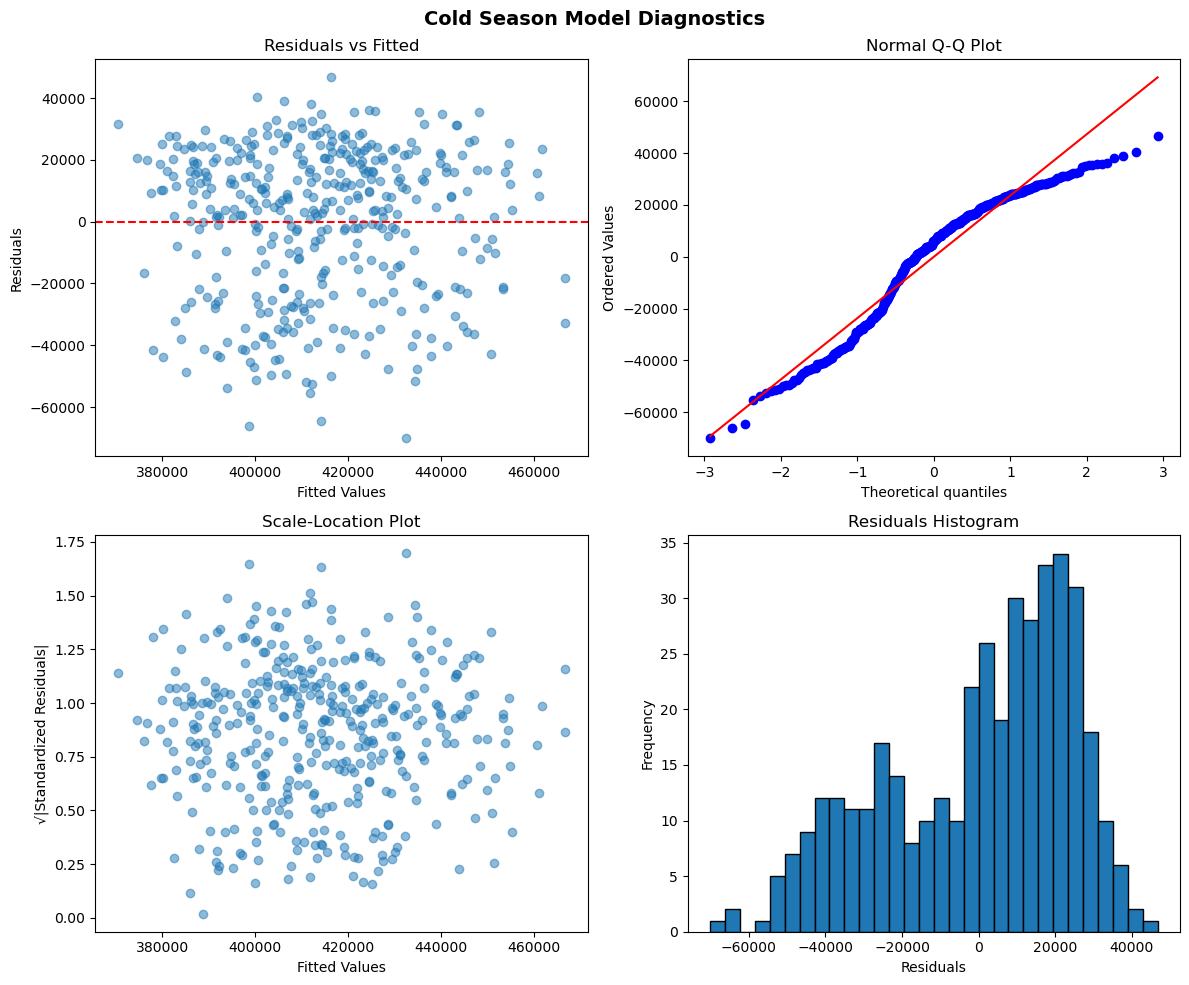

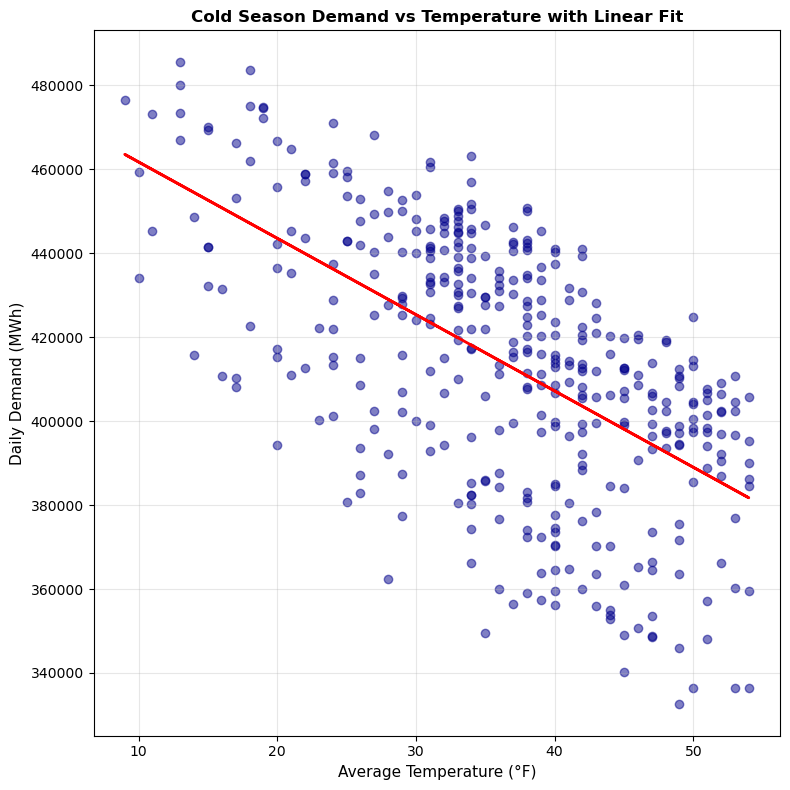

In [20]:
# diagnostic plots: Cold season
residuals = model_cold.resid
fitted_values = model_cold.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted_values, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')

# 3. Scale-Location
standardized_resid = np.sqrt(np.abs(residuals / residuals.std()))
axes[1, 0].scatter(fitted_values, standardized_resid, alpha=0.5)
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('√|Standardized Residuals|')
axes[1, 0].set_title('Scale-Location Plot')

# 4. Residuals Histogram
axes[1, 1].hist(residuals, bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residuals Histogram')

plt.suptitle('Cold Season Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cold_season_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

# Demand vs Avg Temp scatterplot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
x_data = cold_season['TAVG']
y_data = cold_season['daily_demand_MWh']
ax.scatter(x_data, y_data, alpha=0.5, color='darkblue')
m, b = np.polyfit(x_data, y_data, 1)
ax.plot(x_data, m*x_data + b, color='red', linewidth=2, label=f'Linear Fit: y={m:.2f}x+{b:.2f}')
ax.set_xlabel('Average Temperature (°F)', fontsize=11)
ax.set_ylabel('Daily Demand (MWh)', fontsize=11)
ax.set_title('Cold Season Demand vs Temperature with Linear Fit', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cold_season_scatter_with_fit.png', dpi=300, bbox_inches='tight')
plt.show()

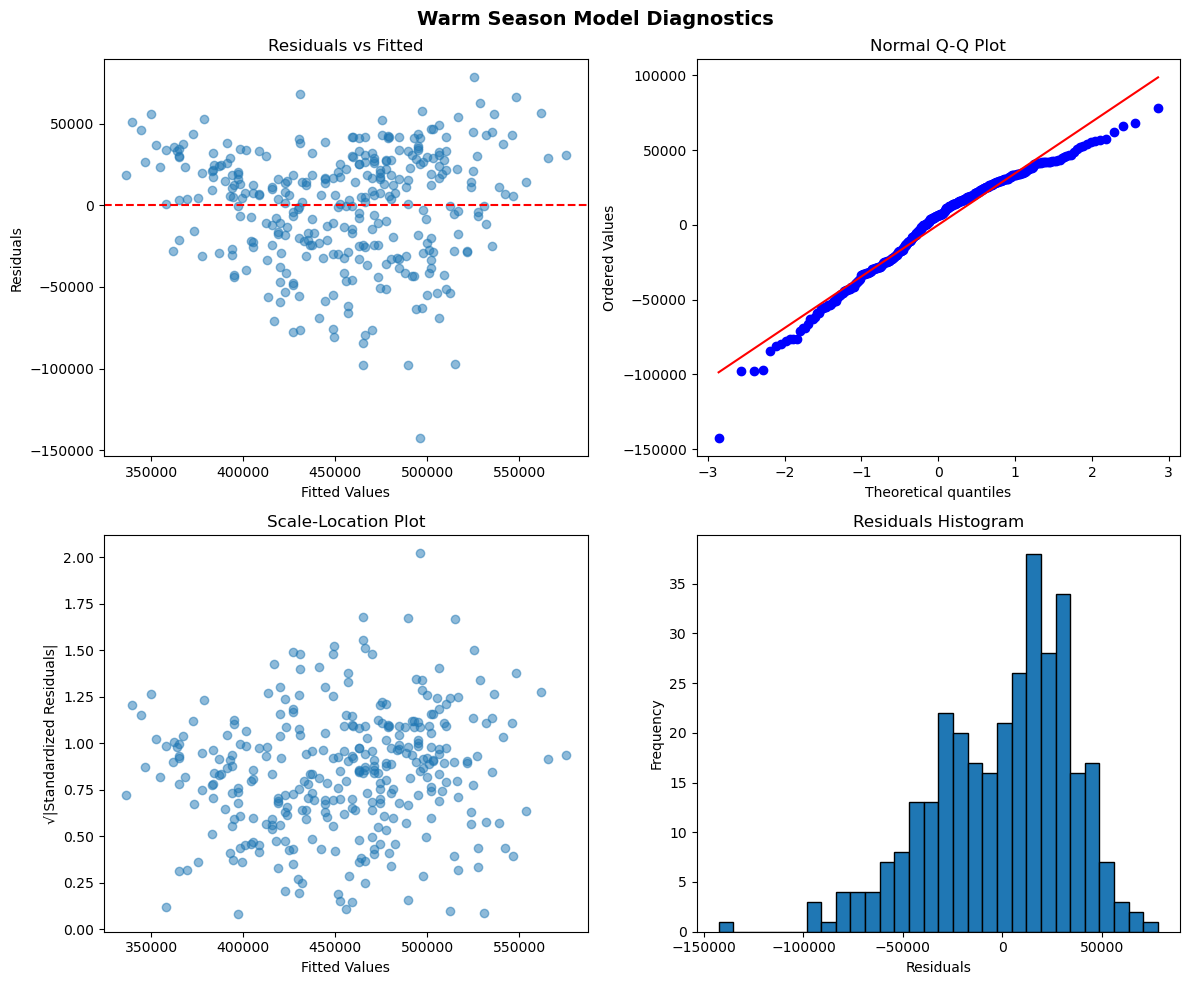

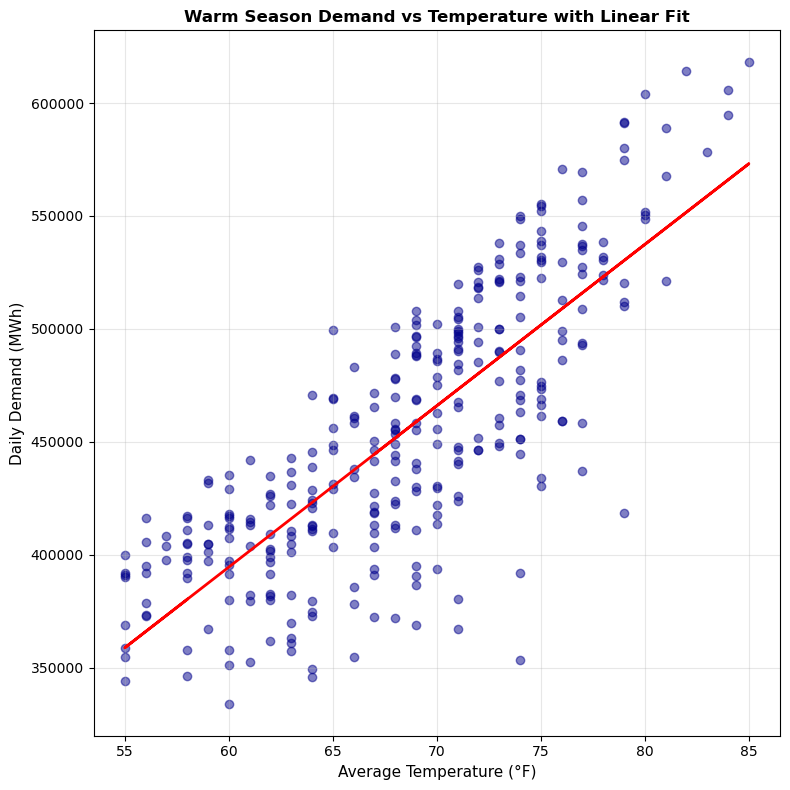

In [21]:
# Diagnostic plots: Warm season
residuals = model_warm.resid
fitted_values = model_warm.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted_values, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')

# 3. Scale-Location
standardized_resid = np.sqrt(np.abs(residuals / residuals.std()))
axes[1, 0].scatter(fitted_values, standardized_resid, alpha=0.5)
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('√|Standardized Residuals|')
axes[1, 0].set_title('Scale-Location Plot')

# 4. Residuals Histogram
axes[1, 1].hist(residuals, bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residuals Histogram')

plt.suptitle('Warm Season Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('warm_season_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

# Demand vs Avg Temp scatterplot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
x_data = warm_season['TAVG']
y_data = warm_season['daily_demand_MWh']
ax.scatter(x_data, y_data, alpha=0.5, color='darkblue')
m, b = np.polyfit(x_data, y_data, 1)
ax.plot(x_data, m*x_data + b, color='red', linewidth=2, label=f'Linear Fit: y={m:.2f}x+{b:.2f}')
ax.set_xlabel('Average Temperature (°F)', fontsize=11)
ax.set_ylabel('Daily Demand (MWh)', fontsize=11)
ax.set_title('Warm Season Demand vs Temperature with Linear Fit', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('warm_season_scatter_with_fit.png', dpi=300, bbox_inches='tight')
plt.show()


Cold Season Test Results
RMSE: 24,754.41 MWh
MAE: 20,222.54 MWh
R²: 0.350

Warm Season Test Results
RMSE: 34,412.48 MWh
MAE: 27,806.15 MWh
R²: 0.684

Overall Test Results (2024)
RMSE: 29,908.90 MWh
MAE: 23,961.83 MWh
R²: 0.679


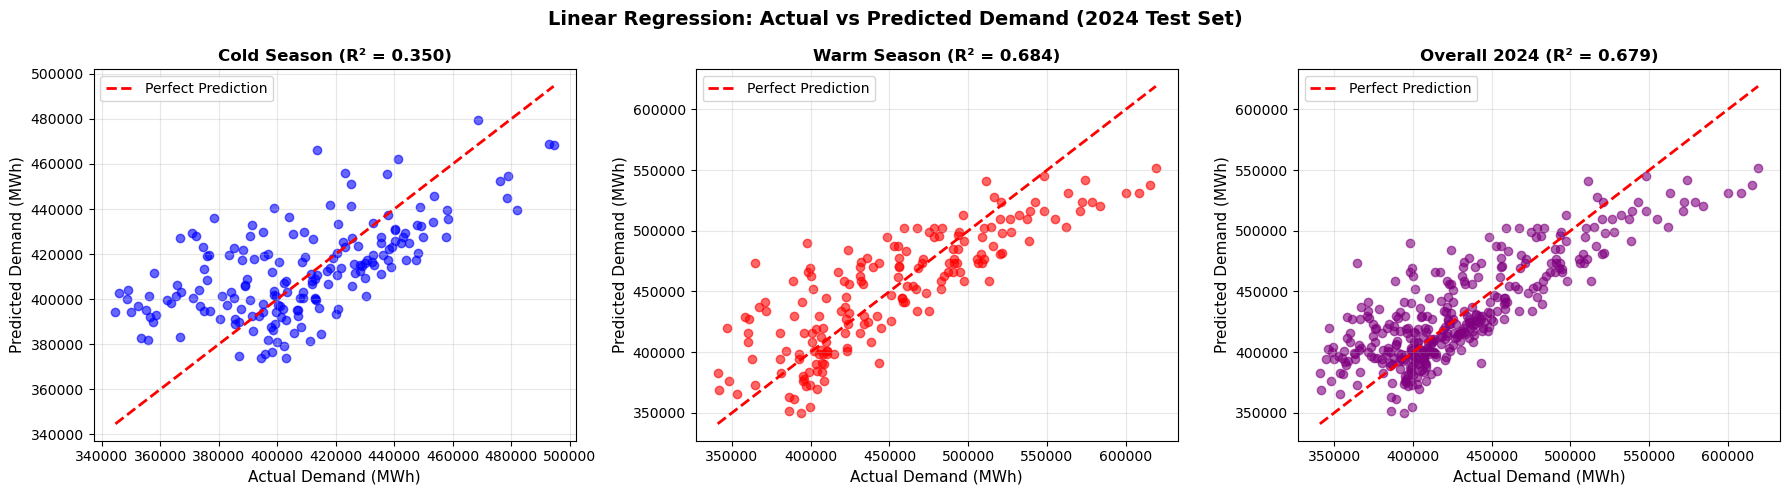

In [22]:
# Predictions on Test Data
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_cold = test_df[test_df['TAVG'] < 55].copy()
test_warm = test_df[test_df['TAVG'] >= 55].copy()

# Cold Season predictions and test metrics
X_test_cold = add_constant(test_cold[['TAVG', 'PRCP', 'RHMN', 'AWND', 'ASTP']])
y_test_cold = test_cold['daily_demand_MWh']
predictions_cold = model_cold.predict(X_test_cold)

rmse_cold = np.sqrt(mean_squared_error(y_test_cold, predictions_cold))
mae_cold = mean_absolute_error(y_test_cold, predictions_cold)
r2_cold = r2_score(y_test_cold, predictions_cold)

print("\nCold Season Test Results")
print(f"RMSE: {rmse_cold:,.2f} MWh")
print(f"MAE: {mae_cold:,.2f} MWh")
print(f"R²: {r2_cold:.3f}")

# Warm Season predictions and test metrics
X_test_warm = add_constant(test_warm[['TAVG', 'RHMX']])
y_test_warm = test_warm['daily_demand_MWh']
predictions_warm = model_warm.predict(X_test_warm)

rmse_warm = np.sqrt(mean_squared_error(y_test_warm, predictions_warm))
mae_warm = mean_absolute_error(y_test_warm, predictions_warm)
r2_warm = r2_score(y_test_warm, predictions_warm)

print("\nWarm Season Test Results")
print(f"RMSE: {rmse_warm:,.2f} MWh")
print(f"MAE: {mae_warm:,.2f} MWh")
print(f"R²: {r2_warm:.3f}")

# Combined results
all_predictions = pd.concat([
    pd.DataFrame({'actual': y_test_cold, 'predicted': predictions_cold}),
    pd.DataFrame({'actual': y_test_warm, 'predicted': predictions_warm})
])

rmse_overall = np.sqrt(mean_squared_error(all_predictions['actual'], all_predictions['predicted']))
mae_overall = mean_absolute_error(all_predictions['actual'], all_predictions['predicted'])
r2_overall = r2_score(all_predictions['actual'], all_predictions['predicted'])

print("\nOverall Test Results (2024)")
print(f"RMSE: {rmse_overall:,.2f} MWh")
print(f"MAE: {mae_overall:,.2f} MWh")
print(f"R²: {r2_overall:.3f}")

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Cold Season
axes[0].scatter(y_test_cold, predictions_cold, alpha=0.6, color='blue')
axes[0].plot([y_test_cold.min(), y_test_cold.max()], 
             [y_test_cold.min(), y_test_cold.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Demand (MWh)', fontsize=11)
axes[0].set_ylabel('Predicted Demand (MWh)', fontsize=11)
axes[0].set_title(f'Cold Season (R² = {r2_cold:.3f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Warm Season
axes[1].scatter(y_test_warm, predictions_warm, alpha=0.6, color='red')
axes[1].plot([y_test_warm.min(), y_test_warm.max()], 
             [y_test_warm.min(), y_test_warm.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Demand (MWh)', fontsize=11)
axes[1].set_ylabel('Predicted Demand (MWh)', fontsize=11)
axes[1].set_title(f'Warm Season (R² = {r2_warm:.3f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Combined
axes[2].scatter(all_predictions['actual'], all_predictions['predicted'], alpha=0.6, color='purple')
axes[2].plot([all_predictions['actual'].min(), all_predictions['actual'].max()], 
             [all_predictions['actual'].min(), all_predictions['actual'].max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Demand (MWh)', fontsize=11)
axes[2].set_ylabel('Predicted Demand (MWh)', fontsize=11)
axes[2].set_title(f'Overall 2024 (R² = {r2_overall:.3f})', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Linear Regression: Actual vs Predicted Demand (2024 Test Set)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

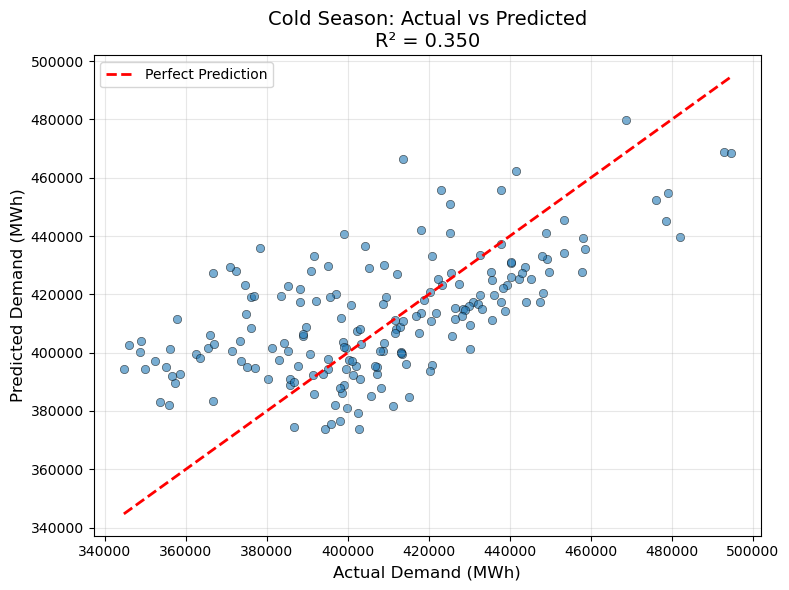

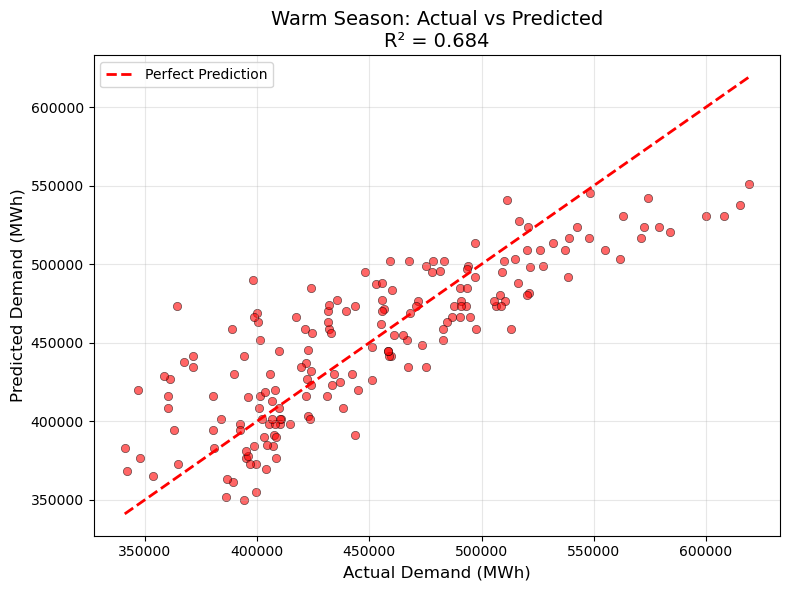

In [23]:
# Plot actual v. predicted values

# Cold Season Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_cold, predictions_cold, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test_cold.min(), y_test_cold.max()], 
         [y_test_cold.min(), y_test_cold.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Demand (MWh)', fontsize=12)
plt.ylabel('Predicted Demand (MWh)', fontsize=12)
plt.title(f'Cold Season: Actual vs Predicted\nR² = {r2_cold:.3f}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cold_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# Warm Season Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_warm, predictions_warm, alpha=0.6, edgecolors='k', linewidth=0.5, color='red')
plt.plot([y_test_warm.min(), y_test_warm.max()], 
         [y_test_warm.min(), y_test_warm.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Demand (MWh)', fontsize=12)
plt.ylabel('Predicted Demand (MWh)', fontsize=12)
plt.title(f'Warm Season: Actual vs Predicted\nR² = {r2_warm:.3f}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('warm_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

**References:**


[1]	Nina Misuraca Ignaczak. 2025. Data centers in Michigan: What you need to know. *Planet Detroit* (November 10, 2025). Retrieved December 2, 2025 from https://planetdetroit.org/2025/11/data-centers-water-energy-impact/

[2]	Kelly House. 2025. Data centers eyed in at least 10 Michigan towns. How they might change state. *Bridge Michigan* (November 19, 2025). Retrieved December 2, 2025 from https://bridgemi.com/michigan-environment-watch/data-centers-eyed-in-at-least-10-michigan-towns-how-they-might-change-state/

[3]	Susan Vela. 2025. $120 million data center proposed in downtown Lansing. What we know. *Lansing State Journal* (November 5, 2025). Retrieved December 2, 2025 from https://www.lansingstatejournal.com/story/money/business/2025/11/05/lansing-data-center-deep-green-bwl/87051236007/

[4]	Ted Brekken. 2024. Frameworks for Analyzing Resilience. In *Resiliency of Power Distribution Systems*, Anurag Srivastava, Chen-Ching Liu, and Sayonsom Chanda (Eds.). John Wiley & Sons, Ltd., 163–182.

[5]	Ciaran Gilbert, Jethro Browell, and Bruce Stephen. 2023. Probabilistic load forecasting for the low voltage network: Forecast fusion and daily peaks. *Sustainable Energy, Grids and Networks* 34 (January 2023). https://doi.org/10.1016/j.segan.2023.100998 

[6]	Heba-Allah Ibrahim El-Azab, R. A. Swief, Noha H. El-Amary, and H. K. Temraz. 2025. Seasonal forecasting of the hourly electricity demand applying machine and deep learning algorithms impact analysis of different factors. *Sci. Rep.* 15, 9252 (2025). https://doi.org/10.1038/s41598-025-91878-0

[7]	Shixiang Zhu, Rui Yao, Yao Xie, Feng Qiu, Yueming (Lucy) Qiu, and Xuan Wu. 2025. Quantifying Grid Resilience Against Extreme Weather Using Large-Scale Customer Power Outage Data. *INFORMS Journal on Data Science* (Sept. 2025). https://doi.org/10.1287/ijds.2023.0017

[8]	Do V, Wilner LB, Flores NM, McBrien H, Northrop AJ, and Casey JA. 2025. Spatiotemporal patterns of individual and multiple simultaneous severe weather events co-occurring with power outages in the United States, 2018–2020. *PLOS Climate* 4, 1 (2025), e0000523. https://doi.org/10.1371/journal.pclm.0000523 

[9]	Barry E. Flanagan, Edward W. Gregory, Elaine J. Hallisey, Janet L. Heitgerd, and Brian Lewis. 2011. A Social Vulnerability Index for Disaster Management. *Journal of Homeland Security and Emergency Management* 8, 1 (2011).

[10]	Karl Rabago and Robin Dutta. 2023. The Economic Impact of Michigan's Unreliable Power Grid. *Local Solar for All.* Retrieved from https://house.mi.gov/Document/?DocumentId=39728&DocumentType=CommitteeTestimony